### Linear regression
###### 입력과 출력의 관계를 가장 잘 나타내는 직선을 찾아, 연속적인 값을 예측하는 알고리즘

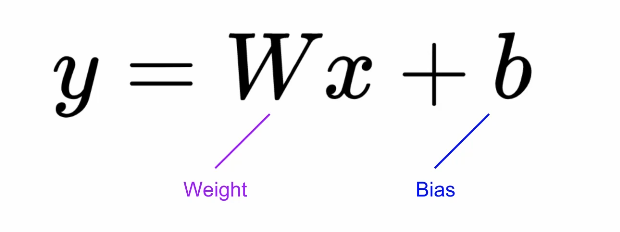

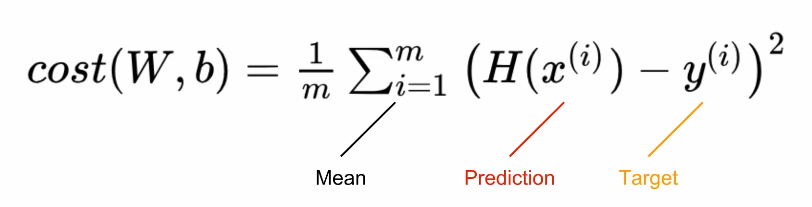


In [ ]:
# W만 학습

import torch
import torch.optim as optim

x_train = torch.FloatTensor([[1], [2], [3]])
y_train = torch.FloatTensor([[1], [2], [3]])

W = torch.zeros(1, requires_grad = True)

optimizer = optim.SGD([W], lr = 0.15)

nb_epoch = 10
for epoch in range(nb_epoch + 1):

    hypothesis = x_train * W
    cost = torch.mean((hypothesis - y_train) ** 2)

    print('Epoch  {:4d}/{} W: {:.3f}, Cost: {:.6f}'.format(epoch, nb_epoch, W.item(), cost.item()))

    optimizer.zero_grad()
    cost.backward()
    optimizer.step()


Epoch     0/10 W: 0.000, Cost: 4.666667
Epoch     1/10 W: 1.400, Cost: 0.746667
Epoch     2/10 W: 0.840, Cost: 0.119467
Epoch     3/10 W: 1.064, Cost: 0.019115
Epoch     4/10 W: 0.974, Cost: 0.003058
Epoch     5/10 W: 1.010, Cost: 0.000489
Epoch     6/10 W: 0.996, Cost: 0.000078
Epoch     7/10 W: 1.002, Cost: 0.000013
Epoch     8/10 W: 0.999, Cost: 0.000002
Epoch     9/10 W: 1.000, Cost: 0.000000
Epoch    10/10 W: 1.000, Cost: 0.000000


### Multivariable Linear regression
#### **nn.Module**: 신경망을 쉽게 만들 수 있도록 필요한 기능들을 미리 구현해 놓은 부모 클래스

In [15]:
# nn 모듈 사용
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

class MultivariateLinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(3,1) # 입력이 3개이고, 출력 특징이 1개인 선현 계층을 만든다. bias는 항상 하나, Weight는 행렬이 (1,3)

    def forward(self, x):
        return self.linear(x)

x_train = torch.FloatTensor([[73, 80, 75],
                             [93, 88, 93],
                             [89, 91, 90],
                             [96, 98, 100],
                             [73, 66, 70]])

y_train = torch.FloatTensor([[152], [185], [180], [196], [142]])

# 모델 초기화

model = MultivariateLinearRegressionModel()

# optimizer 설정
optimizer = optim.SGD(model.parameters(), lr = 1e-5)

nb_epochs = 20
for epoch in range(nb_epochs + 1):
    Hypothesis = model(x_train)

    cost = F.mse_loss(Hypothesis, y_train)

    optimizer.zero_grad()
    cost.backward()
    optimizer.step()


    print('Epoch {:4d}/{} hypothesis: {} Cost: {:.6f}'.format(epoch, nb_epochs, hypothesis.squeeze().detach(), cost.item() ))

Epoch    0/20 hypothesis: tensor([0.9999, 1.9998, 2.9997]) Cost: 36186.406250
Epoch    1/20 hypothesis: tensor([0.9999, 1.9998, 2.9997]) Cost: 11342.718750
Epoch    2/20 hypothesis: tensor([0.9999, 1.9998, 2.9997]) Cost: 3555.543701
Epoch    3/20 hypothesis: tensor([0.9999, 1.9998, 2.9997]) Cost: 1114.677734
Epoch    4/20 hypothesis: tensor([0.9999, 1.9998, 2.9997]) Cost: 349.595978
Epoch    5/20 hypothesis: tensor([0.9999, 1.9998, 2.9997]) Cost: 109.783096
Epoch    6/20 hypothesis: tensor([0.9999, 1.9998, 2.9997]) Cost: 34.614639
Epoch    7/20 hypothesis: tensor([0.9999, 1.9998, 2.9997]) Cost: 11.053139
Epoch    8/20 hypothesis: tensor([0.9999, 1.9998, 2.9997]) Cost: 3.667871
Epoch    9/20 hypothesis: tensor([0.9999, 1.9998, 2.9997]) Cost: 1.352897
Epoch   10/20 hypothesis: tensor([0.9999, 1.9998, 2.9997]) Cost: 0.627228
Epoch   11/20 hypothesis: tensor([0.9999, 1.9998, 2.9997]) Cost: 0.399727
Epoch   12/20 hypothesis: tensor([0.9999, 1.9998, 2.9997]) Cost: 0.328374
Epoch   13/20 hypo

### Loding Data

In [14]:
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

class MultivariateLinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(3,1) # 입력이 3개이고, 출력 특징이 1개인 선현 계층을 만든다. bias는 항상 하나, Weight는 행렬이 (1,3)

    def forward(self, x):
        return self.linear(x)

class CustomDataset(Dataset):
    def __init__(self):
        self.x_data = [[73, 80, 75],
                       [93, 88, 93],
                       [89, 91, 90],
                       [96, 98, 100],
                       [73, 66, 70]]

        self.y_data = [[152], [185], [180], [196], [142]]

    def __len__(self):
        return len(self.x_data)
    def __getitem__(self, idx):
        x = torch.FloatTensor(self.x_data[idx]) # list로 저장했었던 데이터들을 Tensor로 바꿔준다.
        y = torch.FloatTensor(self.y_data[idx])

        return x, y

# 모델 초기화

model = MultivariateLinearRegressionModel()

# optimizer 설정
optimizer = optim.SGD(model.parameters(), lr = 1e-5)


dataset = CustomDataset()

dataloader = DataLoader(
    dataset,
    batch_size = 2,
    shuffle = True,
)

nb_epochs = 20

for epoch in range(nb_epochs + 1):
    for batch_idx, samples in enumerate(dataloader):
        x_train, y_train = samples
        prediction = model(x_train)

        cost = F.mse_loss(prediction, y_train)

        optimizer.zero_grad()
        cost.backward()
        optimizer.step()


        print('Epoch {:4d}/{} hypothesis: {} Cost: {:.6f}'.format(epoch, nb_epochs, hypothesis.squeeze().detach(), cost.item() ))



Epoch    0/20 hypothesis: tensor([0.9999, 1.9998, 2.9997]) Cost: 66747.437500
Epoch    0/20 hypothesis: tensor([0.9999, 1.9998, 2.9997]) Cost: 15942.679688
Epoch    0/20 hypothesis: tensor([0.9999, 1.9998, 2.9997]) Cost: 3046.824951
Epoch    1/20 hypothesis: tensor([0.9999, 1.9998, 2.9997]) Cost: 2592.976562
Epoch    1/20 hypothesis: tensor([0.9999, 1.9998, 2.9997]) Cost: 499.870850
Epoch    1/20 hypothesis: tensor([0.9999, 1.9998, 2.9997]) Cost: 125.975754
Epoch    2/20 hypothesis: tensor([0.9999, 1.9998, 2.9997]) Cost: 80.089043
Epoch    2/20 hypothesis: tensor([0.9999, 1.9998, 2.9997]) Cost: 23.246109
Epoch    2/20 hypothesis: tensor([0.9999, 1.9998, 2.9997]) Cost: 4.810089
Epoch    3/20 hypothesis: tensor([0.9999, 1.9998, 2.9997]) Cost: 3.957361
Epoch    3/20 hypothesis: tensor([0.9999, 1.9998, 2.9997]) Cost: 1.632487
Epoch    3/20 hypothesis: tensor([0.9999, 1.9998, 2.9997]) Cost: 0.011880
Epoch    4/20 hypothesis: tensor([0.9999, 1.9998, 2.9997]) Cost: 0.180172
Epoch    4/20 hypo